In [3]:
%load_ext autoreload
%autoreload 2

In [8]:
import sys
import os
#os.chdir("src")
#sys.path.insert(0, os.path.abspath(os.path.join(os.path.dirname(__file__), '..')))
sys.path.append(os.path.abspath('..'))

In [31]:
tab = np.array([2, 3])
proj_poly(tab)

array([[1., 2., 3., 6., 4., 9.]])

In [9]:
from src.tme3 import *
from src.tme2 import *
np.random.seed(42)

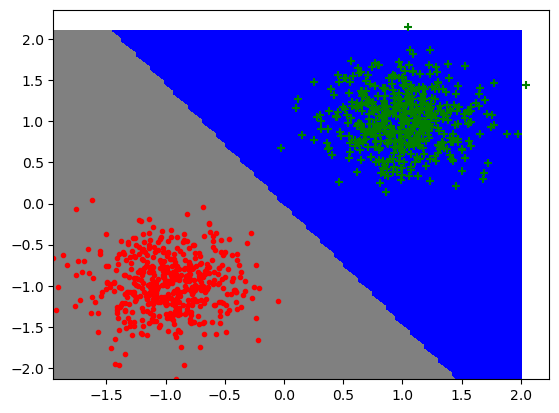

TypeError: Lineaire.fit() got an unexpected keyword argument 'plot_loss'

In [10]:
## Tirage d'un jeu de données aléatoire avec un bruit de 0.1
datax, datay = gen_arti(epsilon=0.1)
## Fabrication d'une grille de discrétisation pour la visualisation de la fonction de coût
grid, x_grid, y_grid = make_grid(xmin=-2, xmax=2, ymin=-2, ymax=2, step=100)

plt.figure()

## Visualisation des données et de la frontière de décision pour un vecteur de poids w
w  = np.random.randn(datax.shape[1],1)
plot_frontiere(datax,lambda x : np.sign(x.dot(w)),step=100)
plot_data(datax,datay)

plt.show()

perceptron = Lineaire(loss=perceptron_loss,loss_g=perceptron_grad,max_iter=100,eps=0.01)
w, losses = perceptron.fit(datax, datay, plot_loss=True)


# Données USPS

Chargement des données

In [12]:
uspsdatatrain = "../data/USPS_train.txt"
uspsdatatest = "../data/USPS_test.txt"
alltrainx,alltrainy = load_usps(uspsdatatrain)
alltestx,alltesty = load_usps(uspsdatatest)
neg = 5
pos = 6
datax,ori_train_labels = get_usps([neg,pos],alltrainx,alltrainy)
datay = np.where(ori_train_labels == 5, -1, 1)
testx,ori_test_labels = get_usps([neg,pos],alltestx,alltesty)
testy = np.where(ori_test_labels == 5, -1, 1)


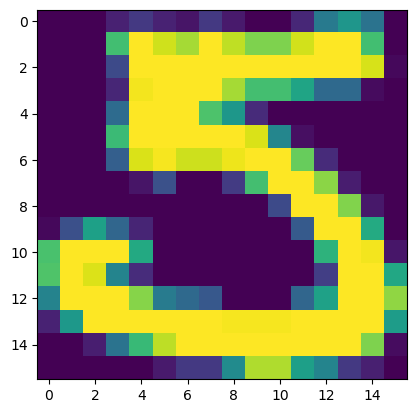

In [13]:
plt.imshow(datax[0].reshape(16,16))

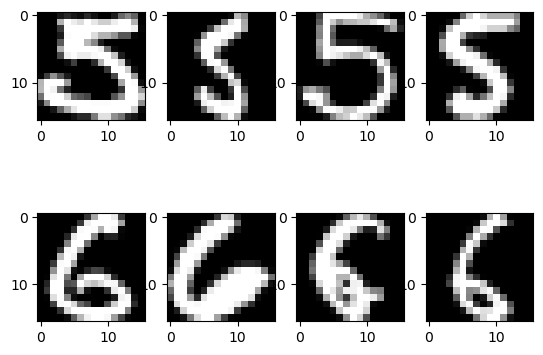

In [14]:
nbl, nbc = 2, 4
fig, axs = plt.subplots(nbl, nbc)

for i in range(nbl*nbc):
    idx = i if i < 4 else -8+i
    axs[i//nbc, i%nbc].imshow(datax[idx].reshape(16,16), cmap="grey")


In [15]:
perceptron = Lineaire(loss=perceptron_loss,loss_g=perceptron_grad,max_iter=100,eps=0.01)
w, losses = perceptron.fit(datax, datay, plot_loss=True)

TypeError: Lineaire.fit() got an unexpected keyword argument 'plot_loss'

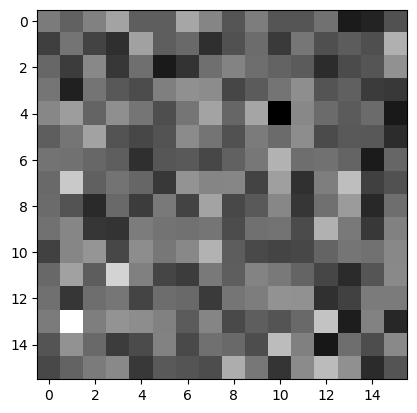

In [ ]:
show_usps(perceptron.w)


One vs All

In [ ]:
uspsdatatrain = "../data/USPS_train.txt"
uspsdatatest = "../data/USPS_test.txt"
alltrainx,alltrainy = load_usps(uspsdatatrain)
alltestx,alltesty = load_usps(uspsdatatest)
pos = 6
l_neg = list(range(0,10))
l_neg.remove(pos)
datax,ori_train_labels = get_usps([l_neg],alltrainx,alltrainy)
datay = np.where(ori_train_labels == 6, 1, -1)
testx,ori_test_labels = get_usps([l_neg,pos],alltestx,alltesty)
testy = np.where(ori_test_labels == 6, 1, -1)

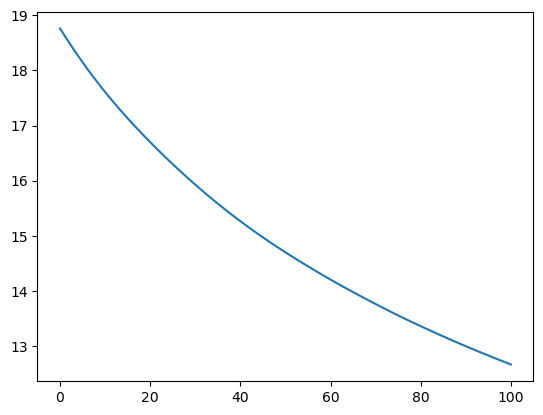

In [ ]:
perceptron = Lineaire(loss=perceptron_loss,loss_g=perceptron_grad,max_iter=100,eps=0.01)
w, losses = perceptron.fit(datax, datay, plot_loss=True)

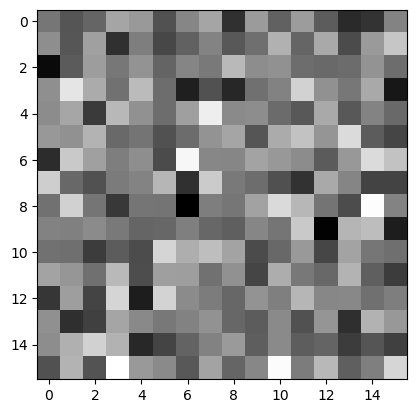

In [ ]:
show_usps(w)

données test dans fit

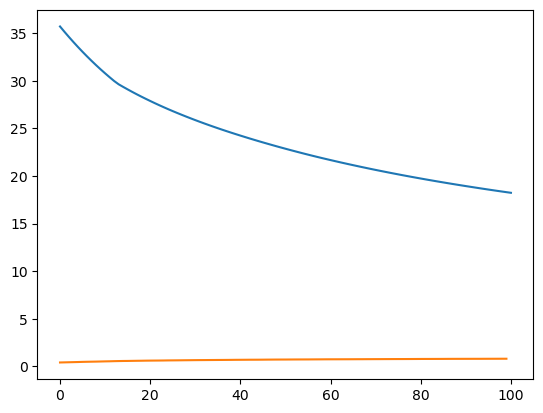

In [ ]:
perceptron = Lineaire(loss=perceptron_loss,loss_g=perceptron_grad,max_iter=100,eps=0.01)
w, losses, scores = perceptron.fit(datax, datay, True, testx, testy)

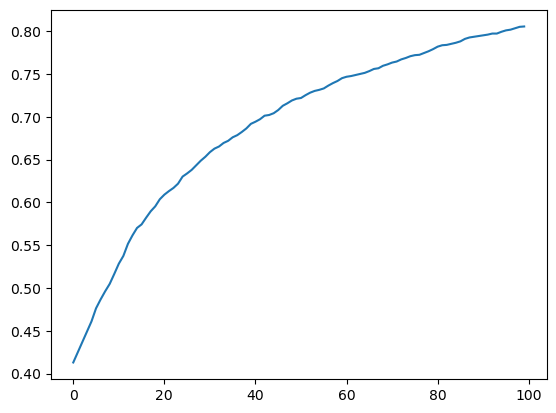

In [ ]:
plt.plot(scores)

Projections

In [ ]:
x = np.array([2, 3])
proj_poly(x)

array([[1, 2, 3, 4, 6, 9]])

In [29]:
x = np.array([2, 3, 4]).reshape(1,-1)
gt1 = np.sqrt(np.dot(x,x.T)) #gt1 = np.sqrt(x@x.T)
gt2 = np.sqrt(np.sum(x*x, axis=1))
res = np.linalg.norm(x, ord=2)

print(gt1)
print(gt2)
print(res)

[[5.38516481]]
[5.38516481]
5.385164807134505
